# Libraries Import

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.feature_selection import f_classif

# Load

In [2]:
Iris = load_iris()

print(Iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [3]:
X = Iris.data
y = Iris.target

print("Features shape: ", X.shape)
print("Features: ", X.shape)

Features shape:  (150, 4)
Features:  (150, 4)


In [4]:
print("Target shape: ", Iris.feature_names)
print("Target: ", Iris.target_names)

Target shape:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target:  ['setosa' 'versicolor' 'virginica']


In [5]:
df = pd.DataFrame(X, columns=Iris.feature_names)

df['species'] = y

df['species'] = df['species'].map(
    {0: 'setosa', 1: 'versicolor', 2: "virginica"}
)

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


# EDA

In [6]:
print("Numbers of Rows: df.shape[0]")
print("Numbers of Columns: df.shape[1]")

Numbers of Rows: df.shape[0]
Numbers of Columns: df.shape[1]


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(1)

In [11]:
print("Species Distribution:")
df['species'].value_counts(normalize=True)*100

Species Distribution:


species
setosa        33.333333
versicolor    33.333333
virginica     33.333333
Name: proportion, dtype: float64

# Visualisations

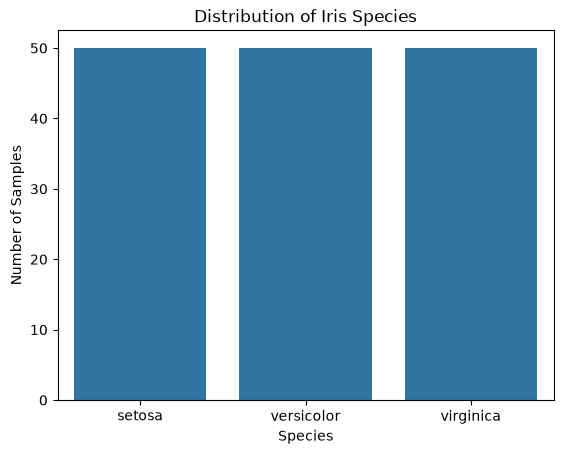

In [12]:
# Count Plot
plt.Figure(figsize=(8,5))

sns.countplot(data=df, x = 'species')

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")

plt.show()

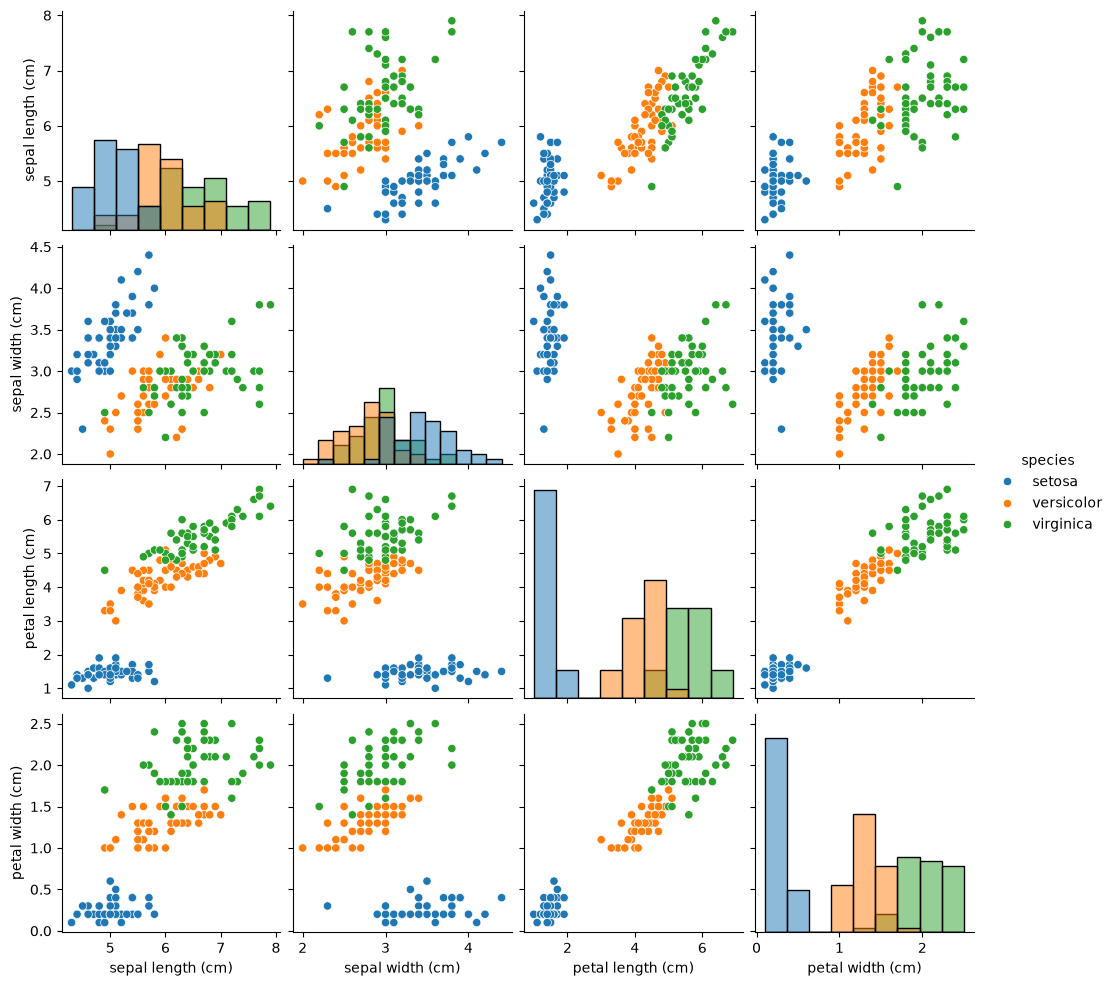

In [13]:
# Pair Plot

sns.pairplot(df, hue = 'species', diag_kind='hist')

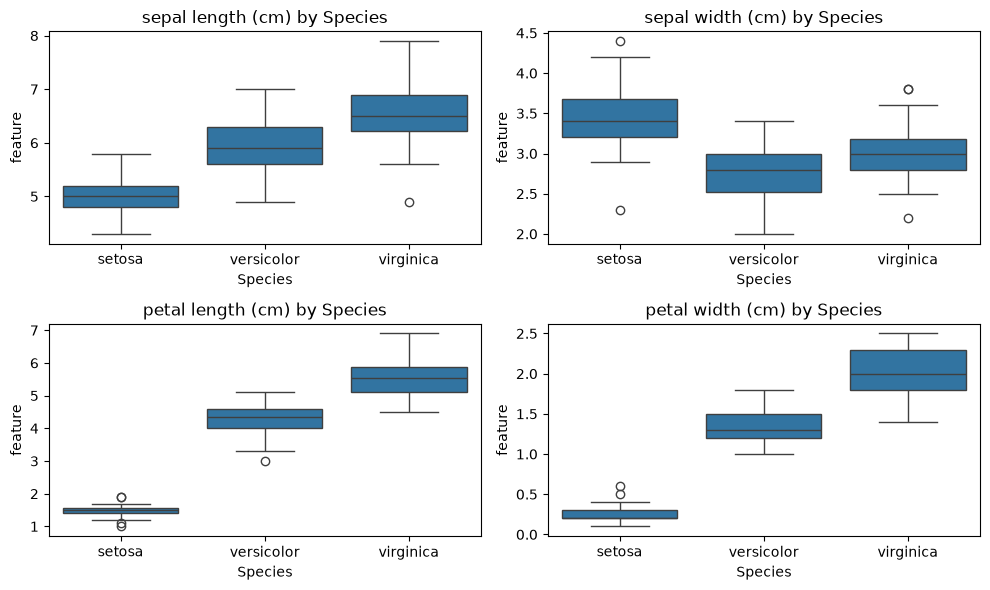

In [14]:
# Box Plot
fig, axes = plt.subplots(2, 2, figsize= (10,6))

features = Iris.feature_names

for ax, feature in zip(axes.flat, features):
    sns.boxplot(data=df, x = 'species', y = feature, ax = ax)
    ax.set_title(f"{feature} by Species")
    ax.set_xlabel('Species')
    ax.set_ylabel('feature')
    
plt.tight_layout()
plt.show()

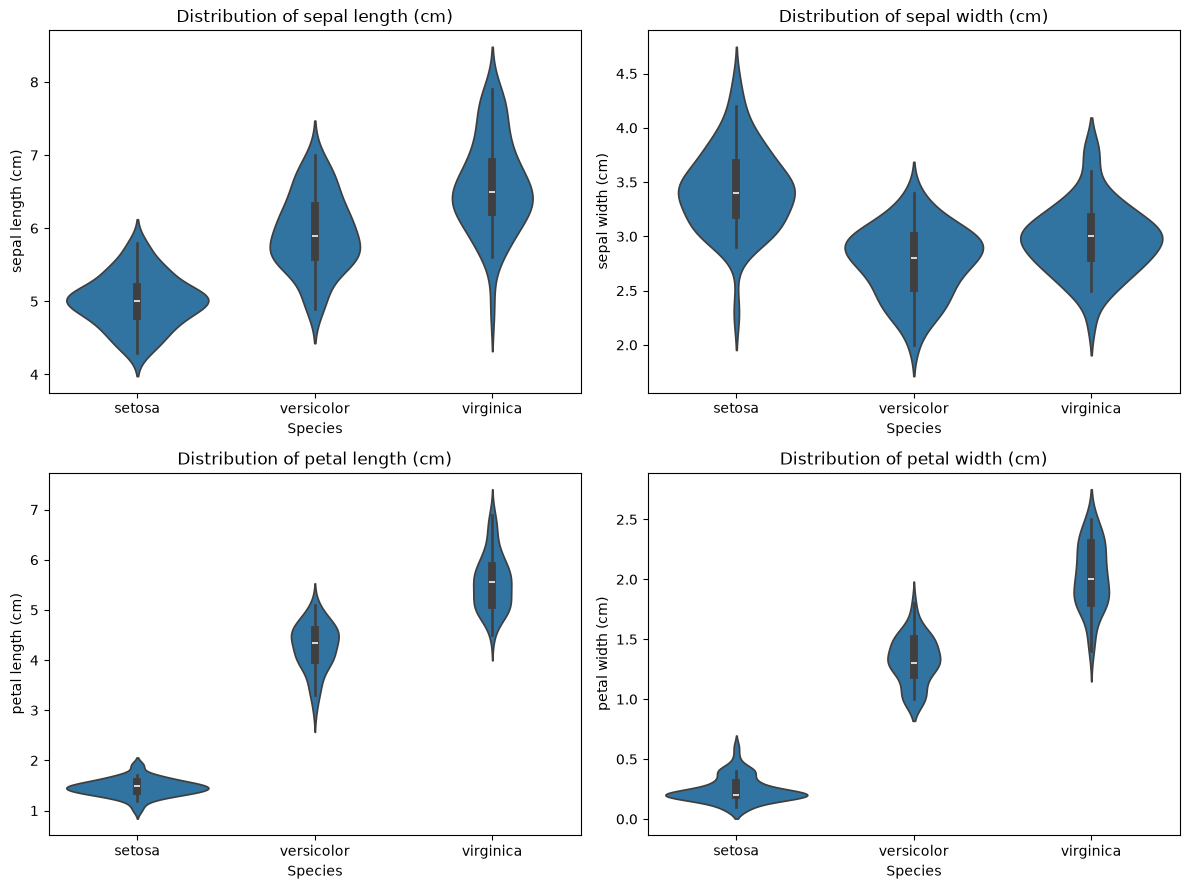

In [15]:
# Violin Plot
fig, axes = plt.subplots(2, 2, figsize = (12,9))

for ax, feature in zip(axes.flat, features):
    sns.violinplot( data=df , x= 'species', y = feature, ax = ax)
    
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel("Species")
    ax.set_ylabel(feature)
    
plt.tight_layout()
plt.show()

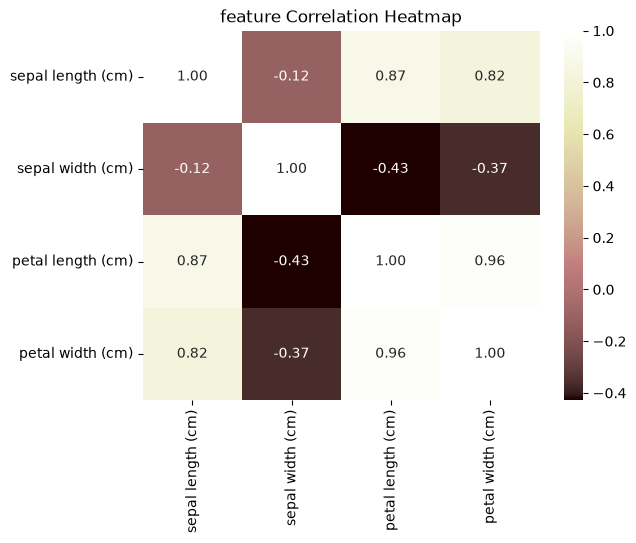

In [16]:
# Co-Realtion Heatmap
plt.Figure(figsize=(10,6))

correlation = df[features].corr()

sns.heatmap(correlation, annot=True,cmap='pink',fmt = '.2f')

plt.title("feature Correlation Heatmap")
plt.show()

# Feature Selection

In [17]:
df.groupby('species')[features].mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [18]:
f_score, p_values = f_classif(X,y)

In [19]:
feature_scores = pd.DataFrame({
    'Feature': Iris.feature_names,
    'F-score': f_score,
    'P-value': p_values
})

feature_scores.sort_values(
    by='F-score',
    ascending=False
)

feature_scores

,Feature,F-score,P-value
0,sepal length (cm),119.264502,1.669669e-31
1,sepal width (cm),49.160040,4.492017e-17
2,petal length (cm),1180.161182,2.856777e-91
3,petal width (cm),960.007147,4.169446e-85


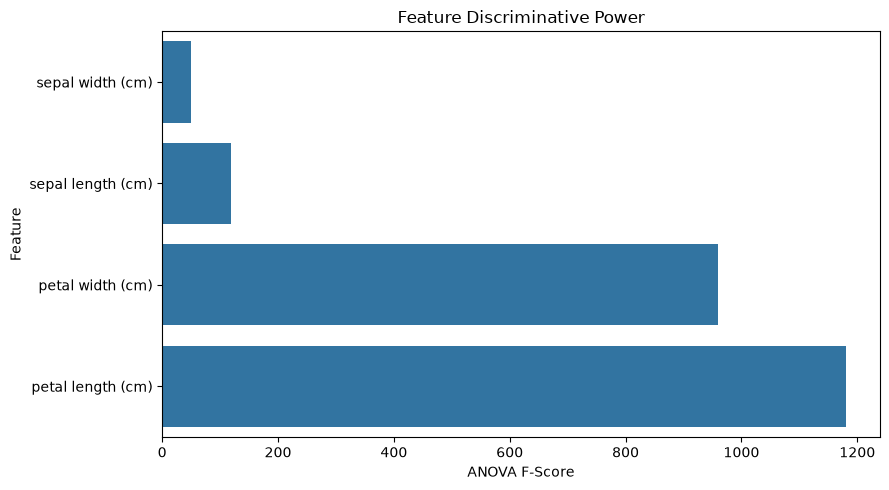

In [20]:
feature_scores_sorted = feature_scores.sort_values(
    by='F-score',
    ascending=True
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_scores_sorted,
    x='F-score',
    y='Feature',
    errorbar=None
)

plt.title('Feature Discriminative Power')
plt.xlabel('ANOVA F-Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [21]:
print(feature_scores)
print(feature_scores.shape)
print(feature_scores.columns)

             Feature      F-score       P-value
0  sepal length (cm)   119.264502  1.669669e-31
1   sepal width (cm)    49.160040  4.492017e-17
2  petal length (cm)  1180.161182  2.856777e-91
3   petal width (cm)   960.007147  4.169446e-85
(4, 3)
Index(['Feature', 'F-score', 'P-value'], dtype='str')


In [22]:
X_selected = df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
# X_selected = df[['petal length (cm)', 'petal width (cm)']]

# Train/Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [24]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (105, 4)
Testing features: (45, 4)
Training target: (105,)
Testing target: (45,)


# Model Training

In [25]:
# Logistic Regression
logistic_model = LogisticRegression()

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
# KNN
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

In [27]:
# Decision Tree
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

y_pred_tree = decision_tree_model.predict(X_test)

In [28]:
# Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

y_pred_forest = random_forest_model.predict(X_test)

# Evaluation 

In [29]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
accuracy_forest = accuracy_score(y_test, y_pred_forest)

print("Logistic Regression:", accuracy_logistic)
print("KNN:", accuracy_knn)
print("Decision Tree:", accuracy_tree)
print("Random Forest:", accuracy_forest)

Logistic Regression: 0.9333333333333333
KNN: 0.9111111111111111
Decision Tree: 0.9333333333333333
Random Forest: 0.8888888888888888


In [30]:
precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    average='weighted'
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    average='weighted'
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic,
    average='weighted'
)

In [31]:
def evaluate_model(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(
            y_true,
            y_pred,
            average='weighted'
        ),
        'Recall': recall_score(
            y_true,
            y_pred,
            average='weighted'
        ),
        'F1-Score': f1_score(
            y_true,
            y_pred,
            average='weighted'
        )
    }

In [32]:
logistic_metrics = evaluate_model(y_test, y_pred_logistic)
knn_metrics = evaluate_model(y_test, y_pred_knn)
tree_metrics = evaluate_model(y_test, y_pred_tree)
forest_metrics = evaluate_model(y_test, y_pred_forest)

results = pd.DataFrame({
    'Logistic Regression': logistic_metrics,
    'KNN': knn_metrics,
    'Decision Tree': tree_metrics,
    'Random Forest': forest_metrics
}).T

In [33]:
results

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.933333,0.934524,0.933333,0.933259
KNN,0.911111,0.929825,0.911111,0.909502
Decision Tree,0.933333,0.944444,0.933333,0.932660
Random Forest,0.888889,0.898148,0.888889,0.887767


In [34]:
print("Logistic Regression")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=Iris.target_names
    )
)

Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



In [35]:
print("KNN")
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=Iris.target_names
    )
)

KNN
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



In [36]:
print("Decision Tree")
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=Iris.target_names
    )
)

Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



In [37]:
print("Random Forest")
print(
    classification_report(
        y_test,
        y_pred_forest,
        target_names=Iris.target_names
    )
)

Random Forest
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



# Best Model

In [38]:
best_model_name = results['F1-Score'].idxmax()

print("Best Model:", best_model_name)
print("Best F1-Score:", results.loc[best_model_name, 'F1-Score'])

Best Model: Logistic Regression
Best F1-Score: 0.9332591768631814


In [39]:
model_comparison = results.sort_values(
    by='F1-Score',
    ascending=False
)

model_comparison

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.933333,0.934524,0.933333,0.933259
Decision Tree,0.933333,0.944444,0.933333,0.932660
KNN,0.911111,0.929825,0.911111,0.909502
Random Forest,0.888889,0.898148,0.888889,0.887767


In [40]:
models = {
    'Logistic Regression': logistic_model,
    'KNN': knn_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model
}

best_model = models[best_model_name]

print("Selected Model:", best_model_name)

Selected Model: Logistic Regression
